# Embed any chain with TCREmp — template

A self-contained template for embedding a repertoire of **any** immune-receptor
chain (`TRA`, `TRB`, `TRG`, `TRD`, `IGH`, `IGK`, `IGL`) with
`mir.embedding.tcremp.TCREmp`. It uses **OLGA-generated mock data** as a stand-in
so it runs end-to-end out of the box, then shows the one-line change to embed
**your own** repertoire.

TCREmp maps each clonotype to a fixed-length vector of distances to a panel of
reference *prototypes*. Two feature sets are available:

* **`vjcdr3`** — V-gene, J-gene, CDR3/junction.
* **`cdr123`** — CDR1, CDR2 (germline V-gene-determined), CDR3/junction.

Embedding needs only the bundled gene library + prototypes — no arda, no mmseqs2,
no network.

In [1]:
import importlib.metadata as _meta, sys as _sys
print(f"Python {_sys.version.split()[0]}")
for _pkg in ["mirpy-lib", "numpy", "scikit-learn", "umap-learn"]:
    try: print(f"  {_pkg}: {_meta.version(_pkg)}")
    except _meta.PackageNotFoundError: pass

import os, sys, time, warnings, re
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, normalize as l2normalize
from sklearn.decomposition import PCA
import umap

repo_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(repo_root) not in sys.path: sys.path.insert(0, str(repo_root))

from mir.basic.pgen import OlgaModel
from mir.common.clonotype import Clonotype
from mir.embedding.tcremp import TCREmp

# ---- configuration -------------------------------------------------------
SPECIES   = "human"     # "human" (all 7 loci) or "mouse" (TRA, TRB)
CHAIN     = "TRB"       # TRA | TRB | TRG | TRD | IGH | IGK | IGL
N_SEQ     = 3000        # number of mock clonotypes to generate
N_PROTO   = 3000        # prototypes (defines embedding width = 3 * N_PROTO)
SEED      = 42
np.random.seed(SEED)
plt.rcParams.update({"font.family": "sans-serif", "figure.dpi": 120,
                     "axes.spines.top": False, "axes.spines.right": False})

Python 3.12.12
  mirpy-lib: 1.1.1
  numpy: 1.26.4
  scikit-learn: 1.3.0
  umap-learn: 0.5.3


/opt/homebrew/anaconda3/lib/python3.12/site-packages/umap/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
# Generate mock clonotypes with OLGA (replace this block with your own data).
t0 = time.perf_counter()
olga = OlgaModel(locus=CHAIN, species=SPECIES, seed=SEED)
records = olga.generate_sequences_with_meta(n=N_SEQ, pgens=False, seed=SEED)
mock_clonotypes = [
    Clonotype(sequence_id=str(i), locus=CHAIN, v_gene=r["v_gene"],
              j_gene=r["j_gene"], junction_aa=r["junction_aa"],
              duplicate_count=1, _validate=False)
    for i, r in enumerate(records)
]
print(f"Generated {len(mock_clonotypes):,} mock {SPECIES} {CHAIN} clonotypes "
      f"in {time.perf_counter()-t0:.1f}s")
print("example:", records[0])

Generated 3,000 mock human TRB clonotypes in 0.1s
example: {'junction_aa': 'CASSWGKGRGLRTDTQYF', 'junction': 'TGCGCCAGCAGCTGGGGAAAGGGGAGGGGCCTCCGCACAGATACGCAGTATTTT', 'v_gene': 'TRBV5-1*01', 'j_gene': 'TRBJ2-3*01', 'v_end': 4, 'j_start': 13}


In [3]:
# Embed with both feature modes (3000 prototypes -> 9000-dim vectors).
embeddings = {}
for mode in ["vjcdr3", "cdr123"]:
    model = TCREmp.from_defaults(SPECIES, CHAIN, n_prototypes=N_PROTO, mode=mode)
    t0 = time.perf_counter()
    X = model.embed(mock_clonotypes, n_jobs=None)
    embeddings[mode] = X
    print(f"{mode}: {X.shape}  in {time.perf_counter()-t0:.1f}s  "
          f"(embedding_dim={model.embedding_dim})")

vjcdr3: (3000, 9000)  in 0.3s  (embedding_dim=9000)
cdr123: (3000, 9000)  in 0.3s  (embedding_dim=9000)


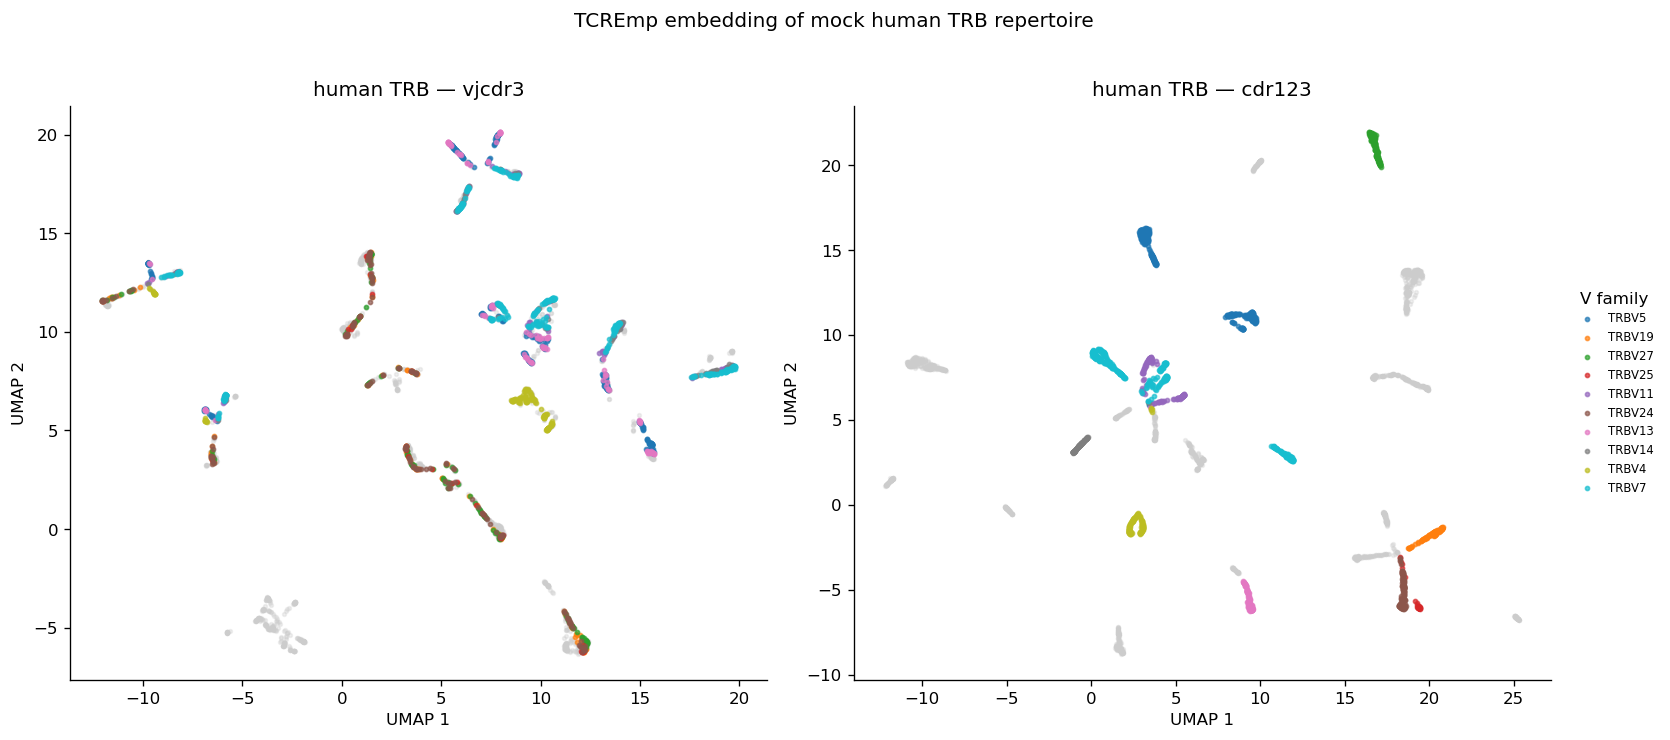

In [4]:
# Sanity check: PCA -> UMAP, coloured by V-gene family.
# Mock data has no antigen labels, so we just confirm the embedding captures
# gene-usage structure (V families form coherent regions).
fams = np.array([re.split(r"[-*]", c.v_gene)[0] for c in mock_clonotypes])
top = list(dict.fromkeys(fams))[:10]
cmap = plt.get_cmap("tab10")
colors = {f: cmap(i) for i, f in enumerate(top)}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, mode in zip(axes, ["vjcdr3", "cdr123"]):
    Xs = StandardScaler().fit_transform(embeddings[mode])
    coords = l2normalize(PCA(n_components=30, random_state=SEED).fit_transform(Xs))
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        xy = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=SEED).fit_transform(coords)
    ax.scatter(xy[~np.isin(fams, top), 0], xy[~np.isin(fams, top), 1],
               c="#cccccc", s=5, alpha=0.3, rasterized=True)
    for f in top:
        m = fams == f
        ax.scatter(xy[m, 0], xy[m, 1], c=[colors[f]], s=6, alpha=0.7,
                   rasterized=True, label=f)
    ax.set_title(f"{SPECIES} {CHAIN} — {mode}")
    ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False,
               fontsize=7, title="V family")
plt.suptitle(f"TCREmp embedding of mock {SPECIES} {CHAIN} repertoire", y=1.02)
plt.tight_layout(); plt.show()

## Embed your own repertoire

Replace the OLGA mock-data step with your repertoire. Any table with V gene,
J gene and CDR3/junction amino-acid columns works; the example below uses the
AIRR rearrangement format (`locus`, `v_call`, `j_call`, `junction_aa`).

```python
from mir.common.parser import AIRRParser

my_clonotypes = AIRRParser(locus=CHAIN).parse("my_repertoire.airr.tsv")
model = TCREmp.from_defaults(SPECIES, CHAIN, n_prototypes=N_PROTO, mode="cdr123")
X = model.embed(my_clonotypes)            # shape: (n_clonotypes, 3 * N_PROTO)
```

The cell below runs that path when the environment variable `REPERTOIRE_PATH`
points to an AIRR file; otherwise it is skipped so the notebook still runs
top-to-bottom.

In [5]:
# Embed a real repertoire if REPERTOIRE_PATH is set (skipped otherwise).
from mir.common.parser import AIRRParser

repertoire_path = os.environ.get("REPERTOIRE_PATH", "")
if repertoire_path and Path(repertoire_path).exists():
    my_clonotypes = AIRRParser(locus=CHAIN).parse(repertoire_path)
    model = TCREmp.from_defaults(SPECIES, CHAIN, n_prototypes=N_PROTO, mode="cdr123")
    X_mine = model.embed(my_clonotypes)
    print(f"Embedded {len(my_clonotypes):,} clonotypes -> {X_mine.shape}")
else:
    print("Set REPERTOIRE_PATH=/path/to/your.airr.tsv to embed your own data; "
          "using mock data only for now.")

Set REPERTOIRE_PATH=/path/to/your.airr.tsv to embed your own data; using mock data only for now.


## Next steps

* Pick the feature set (`mode="vjcdr3"` or `"cdr123"`) that best separates your
  labels — see `tcremp_features_compare.ipynb` for a benchmark.
* Downstream: standardise -> PCA -> (UMAP / DBSCAN) as in
  `tcremp_vdjdb_analysis.ipynb`.
* Installation and a step-by-step walkthrough for new users:
  see the docs page **"Embedding your repertoire"**.